# **_INSTALL DEPENDENCIES_**

In [1]:
import os
import os.path as op
import requests
from urllib.request import urlretrieve
from IPython.display import Markdown, display


def create_folder(folder):
    if not op.exists(folder):
        os.mkdir(folder)
        print(f"Creating:\t\t {folder}")
    else:
        print(f"Already exist:\t\t {folder}")

def download_file(url, filename):
    if not op.exists(filename):
        print(f"Downloading:\t\t {url} --> {filename}")
        urlretrieve(url, filename)
    else:
        print(f"Already downloaded:\t {url} --> {filename}")


FILES = "Files"
EX1DATA1_URL = "https://raw.githubusercontent.com/KeremDUZENLI/python-jupyter-machine-learning/refs/heads/main/notebooks/Files/ex1data1.txt"
EX1DATA1 = FILES + "/ex1data1.txt"
EX1DATA2_URL = "https://raw.githubusercontent.com/KeremDUZENLI/python-jupyter-machine-learning/refs/heads/main/notebooks/Files/ex1data2.txt"
EX1DATA2 = FILES + "/ex1data2.txt"

create_folder(FILES)
download_file(EX1DATA1_URL, EX1DATA1)
download_file(EX1DATA2_URL, EX1DATA2)

Creating:		 Files
Downloading:		 https://raw.githubusercontent.com/KeremDUZENLI/python-jupyter-machine-learning/refs/heads/main/notebooks/Files/ex1data1.txt --> Files/ex1data1.txt
Downloading:		 https://raw.githubusercontent.com/KeremDUZENLI/python-jupyter-machine-learning/refs/heads/main/notebooks/Files/ex1data2.txt --> Files/ex1data2.txt


# Step 1: Import Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Step 2: Identity Matrix


In [4]:
print("Running warmUpExercise ...")
A = np.eye(5)

print("5x5 Identity Matrix:\n", A)

Running warmUpExercise ...
5x5 Identity Matrix:
 [[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]


# Step 3: Load and Visualize Data (Single Variable)


In [11]:
def plotData(x, y):
    plt.plot(x,y, "o")
    plt.show()
    pass

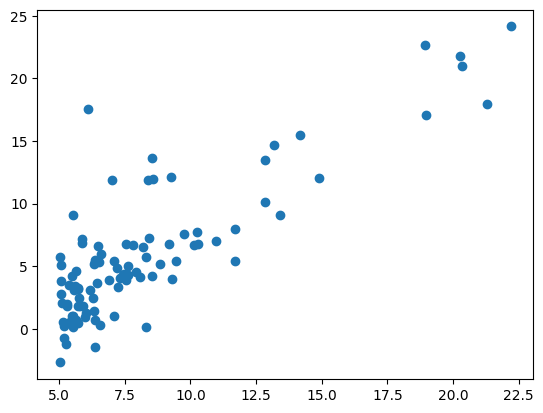

In [42]:
data = np.loadtxt(EX1DATA1)
X = data[:, 0]
y = data[:, 1]
m = y.size

plotData(X, y)

# Step 4: Prepare Data and Test Cost Function


In [43]:
def computeCost(X, y, theta):
    n = y.size
    predictions = X.dot(theta)
    sqrErrors = (predictions - y) ** 2
    J = 1 / (2 * n) * np.sum(sqrErrors)
    
    return J

In [44]:
X_a = np.c_[np.ones((m, 1)), X]
theta = np.zeros(2)

print("Initial cost with theta = [0, 0]:", computeCost(X_a, y, theta))
print("Cost with theta = [-1, 2]:", computeCost(X_a, y, np.array([-1, 2])))

Initial cost with theta = [0, 0]: 32.072733877455676
Cost with theta = [-1, 2]: 54.24245508201238


# Step 5: Run Gradient Descent


In [ ]:
def gradientDescent(X, y, theta, alpha, num_iters):
    """
    Performs gradient descent to learn theta
    """

    m = y.size
    J_history = np.zeros(num_iters)

    for i in range(num_iters):
        predictions = X.dot(theta)
        errors = predictions - y
        theta -= (alpha / m) * (X.T.dot(errors))
        #compute_Cost-ként hivatkozik
        J_history[i] = computeCost(X, y, theta)

    return theta, J_history

In [46]:
iterations = 1500
alpha = 0.01
X_b = np.c_[np.ones((m, 1)), X]

theta, J_history = gradientDescent(X_b, y, theta, alpha, iterations)
print("Theta found by gradient descent:", theta)

Theta found by gradient descent: [-3.63029144  1.16636235]


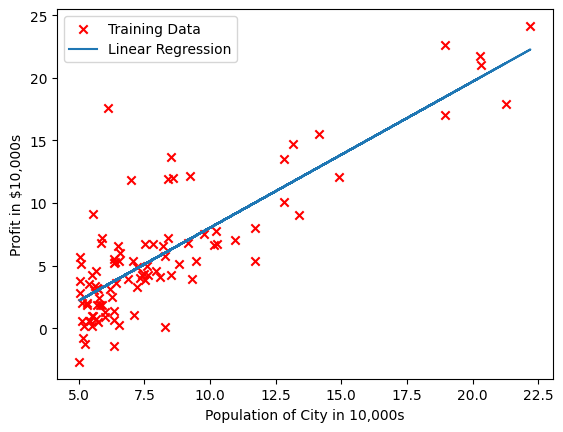

In [ ]:
#Mintában teljes katyvasz
plt.scatter(X_a[:, 1], y, color='red', marker='x', label='Training Data')
plt.plot(X_a[:, 1], X_a.dot(theta), label='Linear Regression')
plt.xlabel("Population of City in 10,000s")
plt.ylabel("Profit in $10,000s")
plt.legend()
plt.show()

# Step 6: Predictions (Single Variable)


In [54]:
predict1 = np.array([1, 3.5]).dot(theta)
predict2 = np.array([1, 7]).dot(theta)

print(f"Predicted profit for population 35,000: ${predict1*10000:.2f}")
print(f"Predicted profit for population 70,000: ${predict2*10000:.2f}")

Predicted profit for population 35,000: $4519.77
Predicted profit for population 70,000: $45342.45


# Step 7: Visualize Cost Function


In [55]:
theta0_vals = np.linspace(-10, 10, 100)
theta1_vals = np.linspace(-1, 4, 100)
J_vals = np.zeros((len(theta0_vals), len(theta1_vals)))

for i, t0 in enumerate(theta0_vals):
    for j, t1 in enumerate(theta1_vals):
        J_vals[i, j] = computeCost(X_b, y, np.array([t0, t1]))

## Step 7.1: Surface Plot


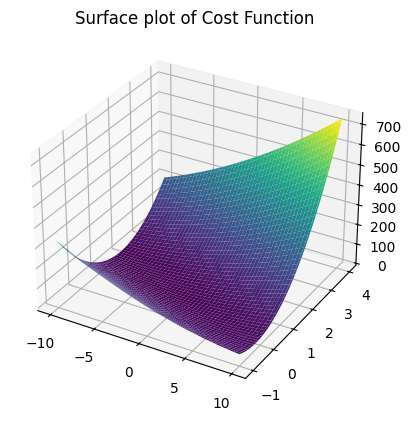

In [56]:
T0, T1 = np.meshgrid(theta0_vals, theta1_vals)

fig = plt.figure()

ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(T0, T1, J_vals.T, cmap='viridis')
ax.set_title("Surface plot of Cost Function")

plt.show()

## Step 7.2: Contour Plot


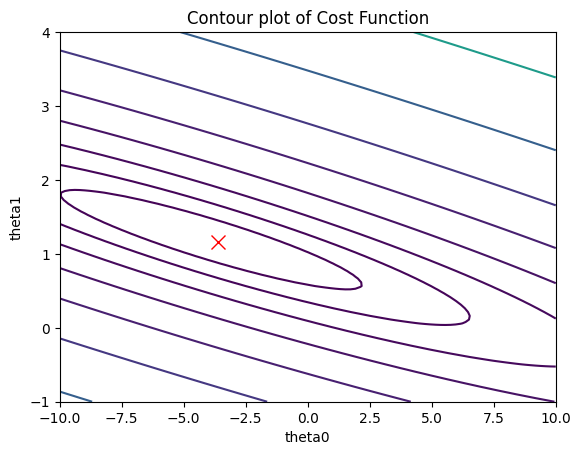

In [57]:
plt.contour(T0, T1, J_vals.T, np.logspace(-2, 3, 20))

plt.plot(theta[0], theta[1], 'rx', markersize=10, linewidth=2)

plt.title("Contour plot of Cost Function")
plt.xlabel("theta0")
plt.ylabel("theta1")

plt.show()

# Step 8: Load Multi-Variable Data and Normalize Features


In [60]:
def feature_normalize(X):
    
    X_norm = X.copy()
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X_norm - mu) / sigma

    return X_norm, mu, sigma

In [61]:
data = np.loadtxt(EX1DATA2, delimiter=',')
X = data[:, 0:2]
y = data[:, 2]
m = y.size

print("First 10 examples from the dataset:")
for i in range(10):
    print(f"x = {X[i]}, y = {y[i]}")

# Normalize features
X_norm, mu, sigma = feature_normalize(X)

# Add intercept term
X_b = np.c_[np.ones(m), X_norm]

First 10 examples from the dataset:
x = [2104.    3.], y = 399900.0
x = [1600.    3.], y = 329900.0
x = [2400.    3.], y = 369000.0
x = [1416.    2.], y = 232000.0
x = [3000.    4.], y = 539900.0
x = [1985.    4.], y = 299900.0
x = [1534.    3.], y = 314900.0
x = [1427.    3.], y = 198999.0
x = [1380.    3.], y = 212000.0
x = [1494.    3.], y = 242500.0


# Step 9: Gradient Descent for Multi-Variable Data


In [62]:
def gradient_descent_multi(X, y, theta, alpha, num_iters):
    """
    Gradient descent for multiple variables
    """

    m = y.size
    theta = np.asarray(theta, dtype=float).reshape(-1)
    J_history = np.zeros(num_iters)

    for i in range(num_iters):
        predictions = X.dot(theta)
        errors = predictions - y
        theta -= (alpha / m) * (X.T.dot(errors))
        
        J_history[i] = computeCost(X, y, theta)

    return theta, J_history

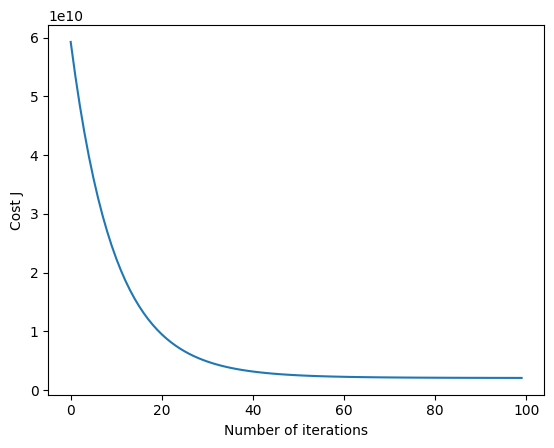

Theta computed from gradient descent: [ 3.38397236e+05  1.03161481e+05 -3.22620198e+02]


In [ ]:
alpha = 0.05 #lehet 0.01, 0.03, 0.1
num_iters = 100 #lehet 1000, 5000, 500, stb.
theta = np.zeros(3)

theta, J_history = gradient_descent_multi(X_b, y, theta, alpha, num_iters)

# Plot convergence
plt.plot(J_history)
plt.xlabel("Number of iterations")
plt.ylabel("Cost J")
plt.show()

print("Theta computed from gradient descent:", theta)

# Step 10: Predict Price


In [ ]:
# Example: predict price of 1650 sq-ft, 3 br house
x_example = np.array([1650, 3])

## Step 10.1: Predict Price Using Gradient Descent


In [81]:
x_example = np.array([1650, 3])

X_norm, mu, sigma = feature_normalize(X)
x_example_norm = (x_example - mu) / sigma

price = np.array([1, *x_example_norm]).dot(theta)

print(f"Predicted price using gradient descent: ${price:.2f}")

Predicted price using gradient descent: $292455.63


## Step 10.2: Predict Price Using Normal Equation


In [76]:
def normal_eqn(X, y):
    
    #TODO: Computes theta using the normal equation
    theta = np.linalg.pinv(X.T.dot(X)).dot(X.T).dot(y) #inverz!!!
    return theta

In [77]:
X_b_full = np.c_[np.ones(m), data[:, 0:2]]
theta_ne = normal_eqn(X_b_full, y)

x_example_b_full = np.r_[1, x_example]
price_ne = x_example_b_full.dot(theta_ne)

print(f"Predicted price using normal equation: ${price_ne:.2f}")

Predicted price using normal equation: $80999.10
